First 5 Rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Gluc

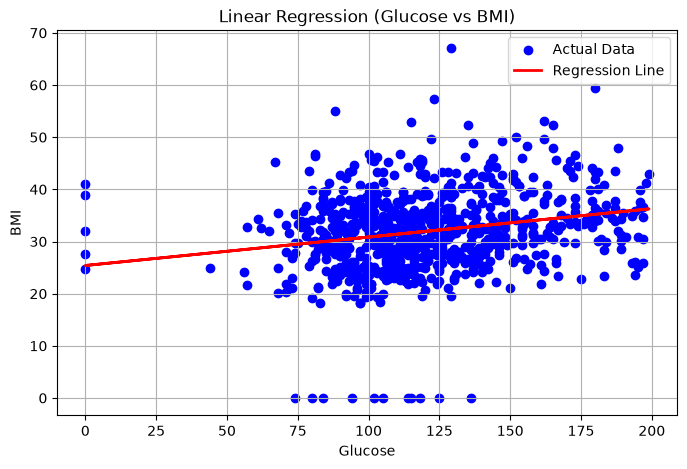


========== Logistic Regression ==========
Features : ['Glucose', 'BloodPressure', 'BMI', 'Age']
Target   : Outcome
Accuracy : 74.03 %


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score

# ---------------------------------------
# Load the Dataset
# ---------------------------------------

df = pd.read_csv("diabetes.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

# ---------------------------------------
# Linear Regression
# Predict BMI using Glucose
# ---------------------------------------

X = df[["Glucose"]]
y = df["BMI"]

linear_model = LinearRegression()
linear_model.fit(X, y)

y_pred = linear_model.predict(X)

print("\n========== Linear Regression ==========")
print("Independent Variable : Glucose")
print("Dependent Variable   : BMI")
print("R² Score :", r2_score(y, y_pred))

# Plot Regression Line

plt.figure(figsize=(8,5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred, color="red", linewidth=2, label="Regression Line")
plt.title("Linear Regression (Glucose vs BMI)")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------
# Logistic Regression
# Predict Diabetes Outcome
# ---------------------------------------

features = ["Glucose", "BloodPressure", "BMI", "Age"]
target = "Outcome"

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n========== Logistic Regression ==========")
print("Features :", features)
print("Target   :", target)
print("Accuracy :", round(accuracy * 100, 2), "%")